# NavigaMer V3.0 仿真基准测试

四个实验对比：NavigaMer C++ / Strobemer / Spaced Seed / Tensor Sketch  
- 实验一: 鲁棒性边界 (Recall vs Error Rate)  
- 实验二: 搜索空间缩减 (ROC-like)  
- 实验三: 全面性 (Sequence Recall & Hit Recall 多拷贝)  
- 实验四: 候选集质量 (Edit Distance 分布)

In [1]:
%matplotlib inline
import os
import sys
import random
import tempfile
import subprocess
import csv
import json
import time
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np

_nb_dir = Path.cwd()
if (_nb_dir / "v3_benchmark.ipynb").exists():
    METHODS_DIR = _nb_dir
elif (_nb_dir / "methods" / "v3_benchmark.ipynb").exists():
    METHODS_DIR = _nb_dir / "methods"
else:
    METHODS_DIR = _nb_dir
PROJECT_DIR = METHODS_DIR.parent
NAVIGAMER_CPP = PROJECT_DIR / "navigamer_cpp"
OUTPUT_DIR = METHODS_DIR / "v3_benchmark_output"
print("METHODS_DIR:", METHODS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

METHODS_DIR: /home/yiru/projects/anchor-based-mapping-main/world_demo/methods
OUTPUT_DIR: /home/yiru/projects/anchor-based-mapping-main/world_demo/methods/v3_benchmark_output


In [2]:
# ── Data generation ──
def load_reference(fasta_path, max_len=10000):
    seq_parts = []
    with open(fasta_path) as f:
        for line in f:
            if line.startswith(">"):
                continue
            seq_parts.append(line.strip().upper())
    return "".join(seq_parts)[:max_len]

def mutate_sequence(sequence, mutation_rate, rng):
    bases = ['A', 'T', 'C', 'G']
    seq_list = list(sequence)
    length = len(seq_list)
    num_mutations = max(1, int(length * mutation_rate))
    for _ in range(num_mutations):
        idx = rng.randint(0, len(seq_list) - 1)
        op = rng.choice(['sub', 'del', 'ins'])
        if op == 'sub':
            original = seq_list[idx]
            choices = [b for b in bases if b != original]
            if choices:
                seq_list[idx] = rng.choice(choices)
        elif op == 'del' and len(seq_list) > length // 2:
            del seq_list[idx]
        elif op == 'ins':
            seq_list.insert(idx, rng.choice(bases))
    return ''.join(seq_list)

def generate_test_data(reference, mutation_rate, num_reads, read_length, seed=42, return_original=False):
    """Returns [(read_id, mutated_seq, true_start, orig_fragment), ...].
    orig_fragment is always included so callers can compute true position sets via find_true_positions().
    return_original is kept for backward-compatibility but has no effect (orig always returned)."""
    rng = random.Random(seed)
    reads = []
    ref_len = len(reference)
    for i in range(num_reads):
        start = rng.randint(0, max(0, ref_len - read_length))
        fragment = reference[start:start + read_length]
        if len(fragment) < read_length:
            continue
        mutated = mutate_sequence(fragment, mutation_rate, rng)
        reads.append((f"read_{i:04d}", mutated, start, fragment))
    return reads


def _simple_edit_dist(a, b):
    """Fast edit distance; used by find_true_positions for short windows."""
    la, lb = len(a), len(b)
    if abs(la - lb) > max(la, lb) // 2:
        return max(la, lb)
    prev = list(range(lb + 1))
    for i, ca in enumerate(a):
        curr = [i + 1] + [0] * lb
        for j, cb in enumerate(b):
            curr[j + 1] = min(prev[j + 1] + 1, curr[j] + 1, prev[j] + (0 if ca == cb else 1))
        prev = curr
    return prev[lb]


def find_true_positions(reference, query_seq, edit_tolerance, window_size=None):
    """Slide *query_seq* (the actual search query, i.e. mutated read) over
    reference and return all start positions where
    edit_distance(reference_window, query_seq) <= edit_tolerance.

    window_size controls the length of the reference window used for
    comparison.  If None it defaults to len(query_seq) (semi-global
    alignment against equal-length windows).  Set it explicitly when the
    index was built with a fixed window size (e.g. NavigaMer uses 100).
    """
    ws = window_size if window_size is not None else len(query_seq)
    positions = []
    for s in range(len(reference) - ws + 1):
        if _simple_edit_dist(reference[s:s + ws], query_seq) <= edit_tolerance:
            positions.append(s)
    return positions

def build_true_sets(reads, reference, edit_tolerance, window_size=None):
    """Pre-compute {read_id -> frozenset(true_start positions)} for all reads.

    Uses the *mutated sequence* (r[1], the actual query) – NOT the original
    fragment – so that the ground truth matches what a search engine actually
    receives as input.
    """
    result = {}
    for r in reads:
        rid, mutated_seq = r[0], r[1]
        result[rid] = frozenset(
            find_true_positions(reference, mutated_seq, edit_tolerance,
                                window_size=window_size))
    return result


def write_fasta(path, name, seq):
    with open(path, 'w') as f:
        f.write(f">{name}\n{seq}\n")

def write_fastq(path, reads):
    with open(path, 'w') as f:
        for r in reads:
            rid, seq = r[0], r[1]
            f.write(f"@{rid}\n{seq}\n+\n{'I' * len(seq)}\n")

In [3]:
# ── Method runners ──
def run_navigamer(ref_fa, query_fq, out_tsv, params):
    binary = NAVIGAMER_CPP / "navigamer"
    if not binary.exists():
        return {"error": f"navigamer not found at {binary}"}
    window = params.get("window_size", 200)
    stride = params.get("stride", 1)
    tol = params.get("tolerance", 5)
    r_sw = params.get("r_sw", 5)    # SW 层半径，默认 R_SW=5
    r_mw = params.get("r_mw", 15)   # MW 层半径，默认 R_MW=15
    r_lw = params.get("r_lw", 30)   # LW 层半径，默认 R_LW=30
    cmd = [str(binary), "benchmark", "--ref", ref_fa, "--reads", query_fq,
           "--tolerance", str(tol), "--window", str(window), "--stride", str(stride),
           "--r-sw", str(r_sw), "--r-mw", str(r_mw), "--r-lw", str(r_lw),
           "--out", out_tsv]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(NAVIGAMER_CPP))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "runtime": elapsed}
    return parse_navigamer_output(out_tsv, elapsed)

def parse_navigamer_output(tsv_path, runtime=0.0):
    hits = defaultdict(list)
    total_leaf_verify = 0
    if not os.path.exists(tsv_path):
        return {"hits": hits, "candidates_count": 0, "runtime": runtime}
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rid = row.get("query_id") or row.get("read_id", "")
            if not rid:
                continue
            try:
                total_leaf_verify += int(row.get("leaf_verify_count", 0))
            except (ValueError, TypeError):
                pass
            ref_start = row.get("reference_start", "")
            if ref_start.isdigit() and row.get("hit_id"):
                hits[rid].append({"ref_start": int(ref_start), "ref_pos": int(ref_start),
                                "edit_dist": int(row.get("edit_distance") or 0), "score": int(row.get("score") or 0)})
    return {"hits": hits, "candidates_count": total_leaf_verify, "runtime": runtime}

def run_strobemer(ref_fa, query_fq, out_tsv, params):
    strobe_dir = METHODS_DIR / "ksahlin" / "strobemers"
    cmd = [sys.executable, str(strobe_dir / "StrobeMap"), "--queries", query_fq, "--references", ref_fa,
           "--outfolder", str(Path(out_tsv).parent), "--prefix", Path(out_tsv).stem, "--k", str(params.get("k", 15)),
           "--strobe_w_min_offset", str(params.get("w_min", 20)), "--strobe_w_max_offset", str(params.get("w_max", 70)),
           "--w", str(params.get("w", 1)), "--n", str(params.get("order", 2)), "--rev_comp"]
    env = os.environ.copy()
    env["PYTHONPATH"] = str(strobe_dir) + os.pathsep + env.get("PYTHONPATH", "")
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, env=env, cwd=str(strobe_dir))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    raw = Path(out_tsv).parent / (Path(out_tsv).stem + ".tsv")
    hits = parse_strobemer_output(str(raw))
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": elapsed}

def parse_strobemer_output(raw_path):
    results = defaultdict(list)
    if not os.path.exists(raw_path):
        return results
    current_query = None
    with open(raw_path) as f:
        for line in f:
            line = line.rstrip("\n")
            if not line:
                continue
            if line.startswith(">"):
                parts = line[2:].strip().split()
                current_query = parts[0] if parts else None
            else:
                fields = line.strip().split()
                if len(fields) >= 4 and current_query:
                    ref_pos = int(fields[1])
                    query_pos = int(fields[2])
                    inferred_start = ref_pos - query_pos
                    results[current_query].append({
                        "ref_pos": inferred_start,
                        "ref_start": inferred_start
                    })
    return results

def run_spaced_seed(ref_fa, query_fq, out_tsv, params):
    ss_dir = METHODS_DIR / "spaced_seed"
    workers = params.get("workers", max(1, os.cpu_count() or 1))
    cmd = [sys.executable, str(ss_dir / "ales_fasta_fastq_align_parallel.py"), "--fasta", ref_fa, "--fastq", query_fq,
           "--output", out_tsv, "--weight", str(params.get("weight", 11)), "--homology-length", str(params.get("homology_length", 64)),
           "--similarity", str(params.get("similarity", 0.8)), "--k-seeds", str(params.get("k_seeds", 1)), "--no-revcomp",
           "--workers", "96"]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True, cwd=str(ss_dir))
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    hits = parse_spaced_seed_output(out_tsv)
    return {"hits": hits, "candidates_count": sum(len(v) for v in hits.values()), "runtime": elapsed}

def parse_spaced_seed_output(tsv_path):
    results = defaultdict(list)
    if not os.path.exists(tsv_path):
        return results
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rid = row.get("read_id", "")
            if rid and rid != "*":
                ref_start = int(row.get("reference_start", 0))
                results[rid].append({"ref_start": ref_start})
    return results

def run_tensor_sketch(ref_fa, query_fq, out_tsv, params):
    binary = METHODS_DIR / "tensor-sketch-alignment" / "metagraph" / "mgsketch_index"
    if not binary.exists():
        return {"error": "mgsketch_index not found", "hits": defaultdict(list), "candidates_count": 0, "runtime": 0}
    cmd = [str(binary), "--ref_fasta", ref_fa, "--query_fastq", query_fq, "--output_tsv", out_tsv,
           "--window_size", str(params.get("window_size", 150)), "--stride", str(params.get("stride", 1)),
           "--hnsw_ef_search", str(params.get("hnsw_ef_search", 50)), "--top_k", str(params.get("top_k", 5))]
    t0 = time.time()
    proc = subprocess.run(cmd, capture_output=True, text=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        return {"error": proc.stderr[:500], "hits": defaultdict(list), "candidates_count": 0, "runtime": elapsed}
    hits = parse_tensor_sketch_output(out_tsv)
    return {"hits": hits, "candidates_count": len(hits) * params.get("top_k", 5), "runtime": elapsed}

def parse_tensor_sketch_output(tsv_path):
    results = defaultdict(list)
    if not os.path.exists(tsv_path):
        return results
    with open(tsv_path) as f:
        reader = csv.DictReader(f, delimiter='\t')
        for row in reader:
            rid = row.get("read_id", "")
            if rid:
                results[rid].append({"ref_start": int(row.get("reference_start", 0))})
    return results

In [4]:
# ── Metrics & Config ──
POS_TOLERANCE = 5

def sequence_recall(match_results, reads, reference=None, edit_tolerance=None,
                    pos_tolerance=POS_TOLERANCE, precomputed_true_sets=None,
                    window_size=None):
    """Recall: fraction of reads with at least one hit landing on a true position.

    Pass precomputed_true_sets (from build_true_sets) to avoid redundant sliding-window
    scans when calling for multiple methods on the same reads.
    Falls back to single-position +/- pos_tolerance when neither is supplied.
    """
    if isinstance(match_results, dict) and "error" in match_results:
        return 0.0, 0
    hits_dict = match_results.get("hits", match_results) if isinstance(match_results, dict) else match_results
    total = len(reads)
    if total == 0:
        return 0.0, 0
    hit_count = 0
    for r in reads:
        rid, true_start = r[0], r[2]
        if precomputed_true_sets is not None:
            true_set = precomputed_true_sets.get(rid)
        elif edit_tolerance is not None and reference is not None:
            true_set = set(find_true_positions(reference, r[1], edit_tolerance,
                                               window_size=window_size))
        else:
            true_set = None
        for m in hits_dict.get(rid, []):
            ref_pos = m.get("ref_pos", m.get("ref_start", -1))
            if ref_pos < 0:
                continue
            if true_set is not None:
                if any(abs(ref_pos - tp) <= pos_tolerance for tp in true_set):
                    hit_count += 1
                    break
            else:
                if abs(ref_pos - true_start) <= pos_tolerance:
                    hit_count += 1
                    break
    return hit_count / total, hit_count

def hit_recall(match_results, ground_truth_positions):
    if isinstance(match_results, dict) and "error" in match_results:
        return 0.0
    hits_dict = match_results.get("hits", match_results)
    all_true = set()
    all_reported = set()
    for rid, true_positions in ground_truth_positions.items():
        for (ref_id, start) in true_positions:
            all_true.add((ref_id, start))
        for m in hits_dict.get(rid, []):
            ref_start = m.get("ref_start", m.get("ref_pos", None))
            if ref_start is not None:
                all_reported.add(("ref", ref_start))
    if not all_true:
        return 1.0
    return len(all_reported & all_true) / len(all_true)

def position_recall(match_results, reads, reference, edit_tolerance,
                    pos_tolerance=POS_TOLERANCE, precomputed_true_sets=None,
                    window_size=None):
    """Position-level recall: fraction of *true mapping positions* recovered by hits.

    For each read, we find all true positions on the reference (via edit-distance
    sliding window on the *mutated sequence*), then check how many of those
    positions are covered by at least one reported hit (within pos_tolerance).
    The final score is the micro-average over all true positions across all reads.
    """
    if isinstance(match_results, dict) and "error" in match_results:
        return 0.0
    hits_dict = match_results.get("hits", match_results) if isinstance(match_results, dict) else match_results
    total_true = 0
    total_found = 0
    for r in reads:
        rid = r[0]
        if precomputed_true_sets is not None:
            true_positions = precomputed_true_sets.get(rid, frozenset())
        else:
            true_positions = frozenset(find_true_positions(
                reference, r[1], edit_tolerance, window_size=window_size))
        if not true_positions:
            continue
        reported = [m.get("ref_pos", m.get("ref_start", -1)) for m in hits_dict.get(rid, [])]
        for tp in true_positions:
            if any(abs(rp - tp) <= pos_tolerance for rp in reported):
                total_found += 1
        total_true += len(true_positions)
    return total_found / total_true if total_true > 0 else 0.0

def candidate_fraction(candidates_count, total_db_size):
    return candidates_count / total_db_size if total_db_size > 0 else 0.0

MUTATION_RATES = [0.01, 0.03, 0.05, 0.07, 0.09, 0.11, 0.13, 0.15]
REF_LENGTH = 10000
READ_LENGTH = 100
NUM_READS_EXP1 = 20
NUM_READS_EXP2 = 20

DEFAULT_PARAMS = {
    "navigamer": {"tolerance": 15, "window_size": 100, "stride": 1, "r_sw": 15, "r_mw": 20, "r_lw": 30},
    "strobemer": {"k": 15, "order": 2, "w_min": 20, "w_max": 30},
    "spaced_seed": {"weight": 10, "similarity": 0.8, "homology_length": 20, "k_seeds": 1},
    "tensor_sketch": {"hnsw_ef_search": 50, "top_k": 5, "window_size": 100, "tuple_size": 3},
}

EXP2_KNOB_SCAN = {
    # NavigaMer: 扫描半径 (Search Radius / Tolerance)
    # 逻辑：半径越大，容错越高，搜索空间越大
    "navigamer": [
        {"tolerance": r, "window_size": 100, "stride": 1, "r_sw": 5, "r_mw": 15, "r_lw": 30} 
        for r in [1, 3, 5,]
    ],

    # Strobemer: 扫描 k-mer 大小 (Seed Specificity)
    # 逻辑：k 越小，容错越高（能匹配更多突变），但噪音/搜索空间指数级增加
    "strobemer": [
        {"k": k, "order": 2, "w_min": 2, "w_max": 10} 
        # for k in [30, 20, 5]
        for k in [30, 25, 20, 10, 3]
    ],

    # Spaced Seed: 扫描权重 (Seed Weight)
    # 逻辑：similarity 越小，容错越高
    "spaced_seed": [
        {"weight": w, "similarity": 0.6, "homology_length": 20, "k_seeds": 1} 
        for w in [5, 9, 12]
        # for s in [0.6, 0.7, 0.8, 0.9, 1.0]
    ],

    # Tensor Sketch: 扫描 Top-K (Search Space Size)
    # 逻辑：top_k 越大，召回率越高，但带回的 Candidate 越多
    # 注意：hnsw_ef_search 固定为 200 (大于最大的 top_k)，确保 HNSW 索引本身的搜索误差不成为瓶颈
    "tensor_sketch": [
        {"hnsw_ef_search": 500, "top_k": k, "window_size": 100, "tuple_size": 3} 
        for k in [5, 10, 150, 500]
        # for k in [1, 10, 20, 50]
    ],
}

In [5]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ecoli_fa = str(PROJECT_DIR / "data" / "ecoli" / "fasta" / "ecoli.fa")
if not os.path.exists(ecoli_fa):
    raise FileNotFoundError(f"Reference not found: {ecoli_fa}")

## 实验一：鲁棒性边界

In [6]:
reference = load_reference(ecoli_fa, max_len=REF_LENGTH)

with open(OUTPUT_DIR / "exp1_robustness.json") as f:
    results_exp1 = json.load(f)
with open(OUTPUT_DIR / "exp1_position_recall.json") as f:
    results_exp1_pos = json.load(f)

results_exp1["spaced_seed"] = []
results_exp1_pos["spaced_seed"] = []

with tempfile.TemporaryDirectory() as tmpdir:
    ref_fa = os.path.join(tmpdir, "ref.fa")
    write_fasta(ref_fa, "ref", reference)
    for mr in MUTATION_RATES:
        print(f"---mutation rate: {mr}---")
        reads = generate_test_data(reference, mr, NUM_READS_EXP1, READ_LENGTH, seed=42 + int(mr * 100))
        query_fq = os.path.join(tmpdir, f"mr{int(mr*100):03d}.fq")
        write_fastq(query_fq, reads)
        edit_tol = DEFAULT_PARAMS["navigamer"]["tolerance"]
        true_sets = build_true_sets(reads, reference, edit_tol,
                                    window_size=READ_LENGTH)
        print("Running spaced_seed")
        out_tsv = os.path.join(tmpdir, f"spaced_seed_{int(mr*100)}.tsv")
        res = run_spaced_seed(ref_fa, query_fq, out_tsv, DEFAULT_PARAMS["spaced_seed"])
        if "error" in res:
            print("  ERROR:", res["error"])
        rec, _ = sequence_recall(res, reads, precomputed_true_sets=true_sets)
        results_exp1["spaced_seed"].append({"mutation_rate": mr, "recall": rec})
        pos_rec = position_recall(res, reads, reference, edit_tol,
                                  precomputed_true_sets=true_sets)
        results_exp1_pos["spaced_seed"].append({"mutation_rate": mr, "recall": pos_rec})
        print(f"  seq_recall={rec:.3f}, pos_recall={pos_rec:.3f}")

with open(OUTPUT_DIR / "exp1_robustness.json", "w") as f:
    json.dump(results_exp1, f, indent=2)
with open(OUTPUT_DIR / "exp1_position_recall.json", "w") as f:
    json.dump(results_exp1_pos, f, indent=2)
print("Exp1 spaced_seed re-run done.")

---mutation rate: 0.01---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
---mutation rate: 0.03---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
---mutation rate: 0.05---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
---mutation rate: 0.07---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
---mutation rate: 0.09---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
---mutation rate: 0.11---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
---mutation rate: 0.13---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
---mutation rate: 0.15---
Running navigamer
Running strobemer
Running spaced_seed
Running tensor_sketch
Exp1 done.


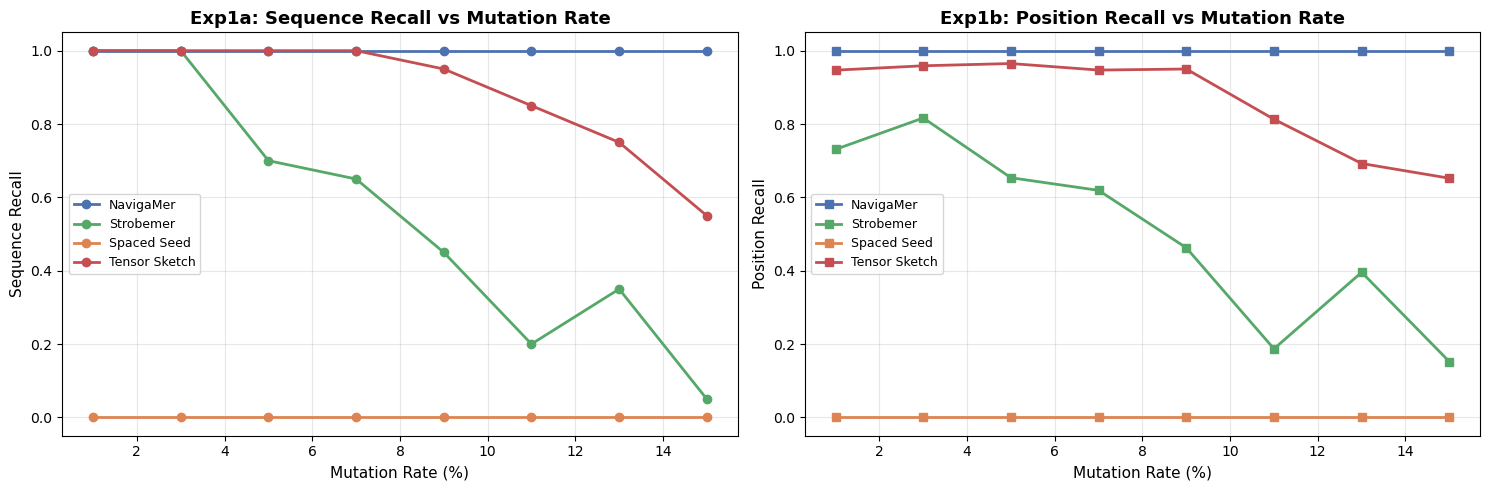

In [7]:
_exp1_colors = {"navigamer": "#4C72B0", "strobemer": "#55A868",
                 "spaced_seed": "#DD8452", "tensor_sketch": "#C44E52"}
_exp1_methods = [("navigamer", "NavigaMer"), ("strobemer", "Strobemer"),
                 ("spaced_seed", "Spaced Seed"), ("tensor_sketch", "Tensor Sketch")]
xs = [int(mr * 100) for mr in MUTATION_RATES]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for method, label in _exp1_methods:
    ys = [r["recall"] for r in results_exp1[method]]
    ax1.plot(xs, ys, marker='o', label=label, linewidth=2, color=_exp1_colors[method])
ax1.set_xlabel("Mutation Rate (%)", fontsize=11)
ax1.set_ylabel("Sequence Recall", fontsize=11)
ax1.set_title("Exp1a: Sequence Recall vs Mutation Rate", fontsize=13, fontweight="bold")
ax1.set_ylim(-0.05, 1.05)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

for method, label in _exp1_methods:
    ys = [r["recall"] for r in results_exp1_pos[method]]
    ax2.plot(xs, ys, marker='s', label=label, linewidth=2, color=_exp1_colors[method])
ax2.set_xlabel("Mutation Rate (%)", fontsize=11)
ax2.set_ylabel("Position Recall", fontsize=11)
ax2.set_title("Exp1b: Position Recall vs Mutation Rate", fontsize=13, fontweight="bold")
ax2.set_ylim(-0.05, 1.05)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "exp1_robustness.png", bbox_inches='tight', dpi=150)
plt.show()

## 实验二：搜索空间缩减

In [8]:
reference = load_reference(ecoli_fa, max_len=REF_LENGTH)
fixed_error = 0.05
reads = generate_test_data(reference, fixed_error, NUM_READS_EXP2, READ_LENGTH, seed=99)
total_windows_ref = max(0, (len(reference) - READ_LENGTH) // 1 + 1)
total_windows_nm = max(0, (len(reference) - 100) // 1 + 1)
series_exp2 = {"navigamer": [], "strobemer": [], "spaced_seed": [], "tensor_sketch": []}

edit_tol = DEFAULT_PARAMS["navigamer"]["tolerance"]
true_sets = build_true_sets(reads, reference, edit_tol, window_size=READ_LENGTH)
with tempfile.TemporaryDirectory() as tmpdir:
    ref_fa = os.path.join(tmpdir, "ref.fa")
    write_fasta(ref_fa, "ref", reference)
    query_fq = os.path.join(tmpdir, "query.fq")
    write_fastq(query_fq, reads)
    for method in ["navigamer", "strobemer", "spaced_seed", "tensor_sketch"]:
        print("Running", method)
        for idx, params in enumerate(EXP2_KNOB_SCAN[method]):
            print("Params", params)
            out_tsv = os.path.join(tmpdir, f"{method}_{idx}.tsv")
            res = run_navigamer(ref_fa, query_fq, out_tsv, params) if method == "navigamer" else \
                   run_strobemer(ref_fa, query_fq, out_tsv, params) if method == "strobemer" else \
                   run_spaced_seed(ref_fa, query_fq, out_tsv, params) if method == "spaced_seed" else \
                   run_tensor_sketch(ref_fa, query_fq, out_tsv, params)
            rec, _ = sequence_recall(res, reads, precomputed_true_sets=true_sets)
            cand = res.get("candidates_count", 0)
            denominator = total_windows_nm if method == "navigamer" else total_windows_ref
            frac = candidate_fraction(cand, denominator * len(reads))
            # frac = candidate_fraction(cand, total_windows_nm if method == "navigamer" else total_windows_ref * len(reads))
            series_exp2[method].append({"recall": rec, "candidate_fraction": max(1e-6, frac), "params": params})

with open(OUTPUT_DIR / "exp2_search_space.json", "w") as f:
    json.dump(series_exp2, f, indent=2, default=str)
print("Exp2 done.")

Running navigamer
Params {'tolerance': 1, 'window_size': 100, 'stride': 1, 'r_sw': 5, 'r_mw': 15, 'r_lw': 30}
Params {'tolerance': 3, 'window_size': 100, 'stride': 1, 'r_sw': 5, 'r_mw': 15, 'r_lw': 30}
Params {'tolerance': 5, 'window_size': 100, 'stride': 1, 'r_sw': 5, 'r_mw': 15, 'r_lw': 30}
Running strobemer
Params {'k': 30, 'order': 2, 'w_min': 2, 'w_max': 10}
Params {'k': 25, 'order': 2, 'w_min': 2, 'w_max': 10}
Params {'k': 20, 'order': 2, 'w_min': 2, 'w_max': 10}
Params {'k': 10, 'order': 2, 'w_min': 2, 'w_max': 10}
Params {'k': 3, 'order': 2, 'w_min': 2, 'w_max': 10}
Running spaced_seed
Params {'weight': 5, 'similarity': 0.6, 'homology_length': 20, 'k_seeds': 1}
Params {'weight': 9, 'similarity': 0.6, 'homology_length': 20, 'k_seeds': 1}
Params {'weight': 12, 'similarity': 0.6, 'homology_length': 20, 'k_seeds': 1}
Running tensor_sketch
Params {'hnsw_ef_search': 500, 'top_k': 5, 'window_size': 100, 'tuple_size': 3}
Params {'hnsw_ef_search': 500, 'top_k': 10, 'window_size': 100, '

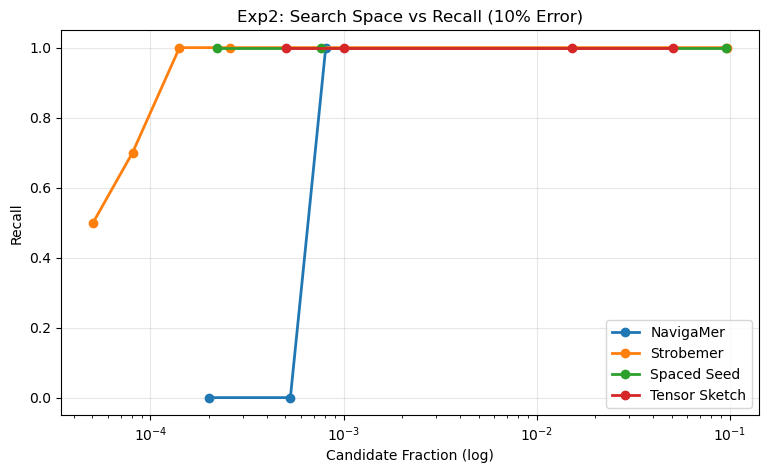

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for method, label in [("navigamer", "NavigaMer"), ("strobemer", "Strobemer"), ("spaced_seed", "Spaced Seed"), ("tensor_sketch", "Tensor Sketch")]:
    pts = series_exp2[method]
    ax.plot([p["candidate_fraction"] for p in pts], [p["recall"] for p in pts], marker='o', label=label, linewidth=2)
ax.set_xlabel("Candidate Fraction")
ax.set_ylabel("Recall")
ax.set_title("Exp2: Search Space vs Recall (10% Error)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.savefig(OUTPUT_DIR / "exp2_search_space_roc.png", bbox_inches='tight')
plt.show()

## 实验三：全面性 (Sequence Recall & Hit Recall)

In [10]:
# reference = load_reference(ecoli_fa, max_len=REF_LENGTH)
# rng = random.Random(42)
# fragment_len = 100
# start0 = rng.randint(0, len(reference) - fragment_len - 1)
# fragment = reference[start0:start0 + fragment_len]
# gap = 100
# ref_multi = fragment + "N" * gap + fragment + "N" * gap + fragment
# true_positions = [0, fragment_len + gap, 2 * (fragment_len + gap)]
# query_seq = mutate_sequence(fragment, 0.05, rng)
# ground_truth = {"read_multi": set(("ref", p) for p in true_positions)}

# reads_exp3 = [("read_multi", query_seq, true_positions[0], fragment)]

# hit_recalls = {}
# seq_recalls = {}
# with tempfile.TemporaryDirectory() as tmpdir:
#     ref_fa = os.path.join(tmpdir, "ref.fa")
#     write_fasta(ref_fa, "ref", ref_multi)
#     query_fq = os.path.join(tmpdir, "q.fq")
#     with open(query_fq, "w") as f:
#         f.write(f"@read_multi\n{query_seq}\n+\n{'I'*len(query_seq)}\n")
#     true_sets = build_true_sets(reads_exp3, ref_multi,
#                                 edit_tolerance=DEFAULT_PARAMS["navigamer"]["tolerance"],
#                                 window_size=fragment_len)
#     for method, params in DEFAULT_PARAMS.items():
#         out_tsv = os.path.join(tmpdir, f"{method}.tsv")
#         res = run_navigamer(ref_fa, query_fq, out_tsv, params) if method == "navigamer" else \
#                run_strobemer(ref_fa, query_fq, out_tsv, params) if method == "strobemer" else \
#                run_spaced_seed(ref_fa, query_fq, out_tsv, params) if method == "spaced_seed" else \
#                run_tensor_sketch(ref_fa, query_fq, out_tsv, params)
#         hit_recalls[method] = hit_recall(res, ground_truth)
#         sr, _ = sequence_recall(res, reads_exp3, precomputed_true_sets=true_sets)
#         seq_recalls[method] = sr

# with open(OUTPUT_DIR / "exp3_comprehensiveness.json", "w") as f:
#     json.dump({"hit_recall": hit_recalls, "sequence_recall": seq_recalls}, f, indent=2)
# print("Exp3 done.")

## 实验四：候选集质量分布

In [11]:
def levenshtein(a, b):
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            dp[i][j] = min(dp[i-1][j]+1, dp[i][j-1]+1, dp[i-1][j-1]+ (0 if a[i-1]==b[j-1] else 1))
    return dp[m][n]

reference = load_reference(ecoli_fa, max_len=REF_LENGTH)
reads = generate_test_data(reference, 0.15, 8, READ_LENGTH, seed=88, return_original=True)
dists_by_method = {}
with tempfile.TemporaryDirectory() as tmpdir:
    ref_fa = os.path.join(tmpdir, "ref.fa")
    write_fasta(ref_fa, "ref", reference)
    query_fq = os.path.join(tmpdir, "q.fq")
    write_fastq(query_fq, reads)
    for method in ["navigamer", "strobemer", "spaced_seed", "tensor_sketch"]:
        params = DEFAULT_PARAMS[method].copy()
        if method == "navigamer": params["tolerance"] = 15
        elif method == "strobemer": params["k"] = 10
        elif method == "spaced_seed": params["weight"] = 8
        else: params["hnsw_ef_search"] = 200
        out_tsv = os.path.join(tmpdir, f"{method}.tsv")
        res = run_navigamer(ref_fa, query_fq, out_tsv, params) if method == "navigamer" else \
               run_strobemer(ref_fa, query_fq, out_tsv, params) if method == "strobemer" else \
               run_spaced_seed(ref_fa, query_fq, out_tsv, params) if method == "spaced_seed" else \
               run_tensor_sketch(ref_fa, query_fq, out_tsv, params)
        hits_dict = res.get("hits", {})
        dists = []
        for r in reads:
            rid, query_seq, true_start, orig = r[0], r[1], r[2], r[3]
            for m in hits_dict.get(rid, []):
                if method == "navigamer" and "edit_dist" in m:
                    dists.append(m["edit_dist"])
                else:
                    ref_start = m.get("ref_start", m.get("ref_pos"))
                    if ref_start is None: continue
                    ref_frag = reference[ref_start:ref_start + len(query_seq)] if ref_start + len(query_seq) <= len(reference) else ""
                    if ref_frag: dists.append(levenshtein(query_seq, ref_frag))
        dists_by_method[method] = dists if dists else [0]

with open(OUTPUT_DIR / "exp4_candidate_quality.json", "w") as f:
    json.dump(dists_by_method, f, indent=2)
print("Exp4 done.")

Exp4 done.


/tmp/ipykernel_15806/2589990730.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,


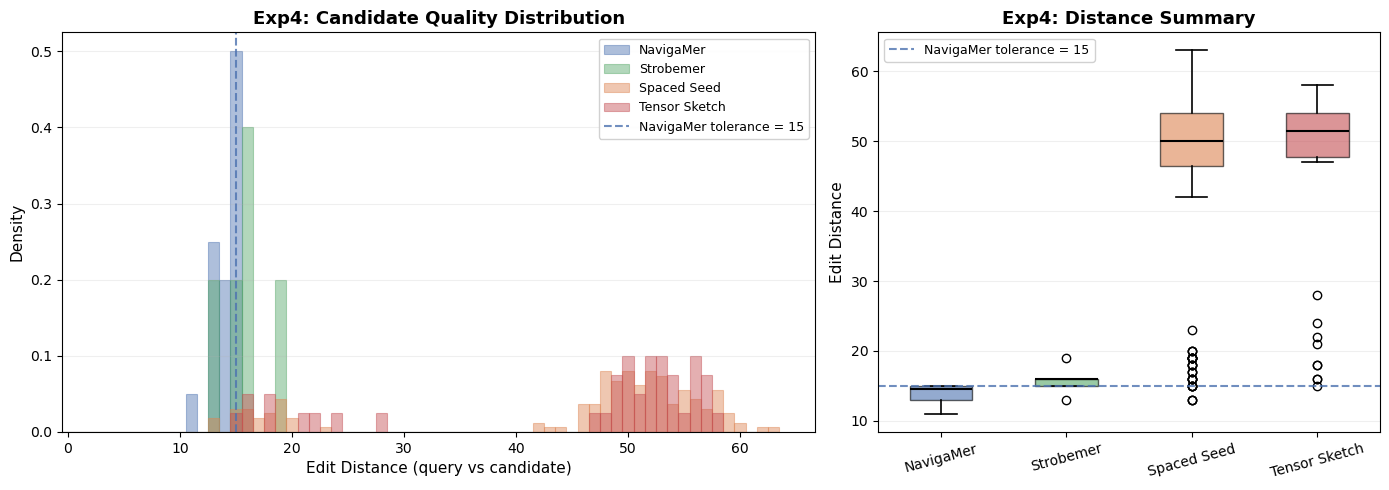

In [12]:
METHOD_COLORS = {"navigamer": "#4C72B0", "strobemer": "#55A868",
                  "spaced_seed": "#DD8452", "tensor_sketch": "#C44E52"}
METHOD_LABELS = {"navigamer": "NavigaMer", "strobemer": "Strobemer",
                 "spaced_seed": "Spaced Seed", "tensor_sketch": "Tensor Sketch"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [3, 2]})

# ── Left: overlaid histogram (density) ──
ax = axes[0]
all_dists = [v for vs in dists_by_method.values() for v in vs if v <= 80]
if all_dists:
    bin_lo, bin_hi = 0, max(all_dists) + 1
    bins = np.arange(bin_lo, bin_hi + 1) - 0.5
else:
    bins = 20

for method in ["navigamer", "strobemer", "spaced_seed", "tensor_sketch"]:
    d = np.array([x for x in dists_by_method.get(method, []) if x <= 80])
    if len(d) == 0:
        continue
    ax.hist(d, bins=bins, alpha=0.45, density=True, label=METHOD_LABELS[method],
            color=METHOD_COLORS[method], edgecolor=METHOD_COLORS[method], linewidth=0.8)

nav_tol = 15
ax.axvline(nav_tol, color="#4C72B0", linestyle="--", linewidth=1.5, alpha=0.8,
           label=f"NavigaMer tolerance = {nav_tol}")
ax.set_xlabel("Edit Distance (query vs candidate)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Exp4: Candidate Quality Distribution", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.2, axis="y")
ax.set_xlim(left=-0.5)

# ── Right: box plot ──
ax2 = axes[1]
box_data, box_labels, box_colors = [], [], []
for method in ["navigamer", "strobemer", "spaced_seed", "tensor_sketch"]:
    d = [x for x in dists_by_method.get(method, []) if x <= 80]
    if d:
        box_data.append(d)
        box_labels.append(METHOD_LABELS[method])
        box_colors.append(METHOD_COLORS[method])

bp = ax2.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.5,
                 medianprops=dict(color="black", linewidth=1.5),
                 whiskerprops=dict(linewidth=1.2),
                 capprops=dict(linewidth=1.2))
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax2.axhline(nav_tol, color="#4C72B0", linestyle="--", linewidth=1.5, alpha=0.8,
            label=f"NavigaMer tolerance = {nav_tol}")
ax2.set_ylabel("Edit Distance", fontsize=11)
ax2.set_title("Exp4: Distance Summary", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9, loc="upper left", framealpha=0.9)
ax2.grid(True, alpha=0.2, axis="y")
ax2.tick_params(axis="x", rotation=15)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "exp4_distance_density.png", bbox_inches='tight', dpi=150)
plt.show()

## 汇总图

NameError: name 'keys' is not defined

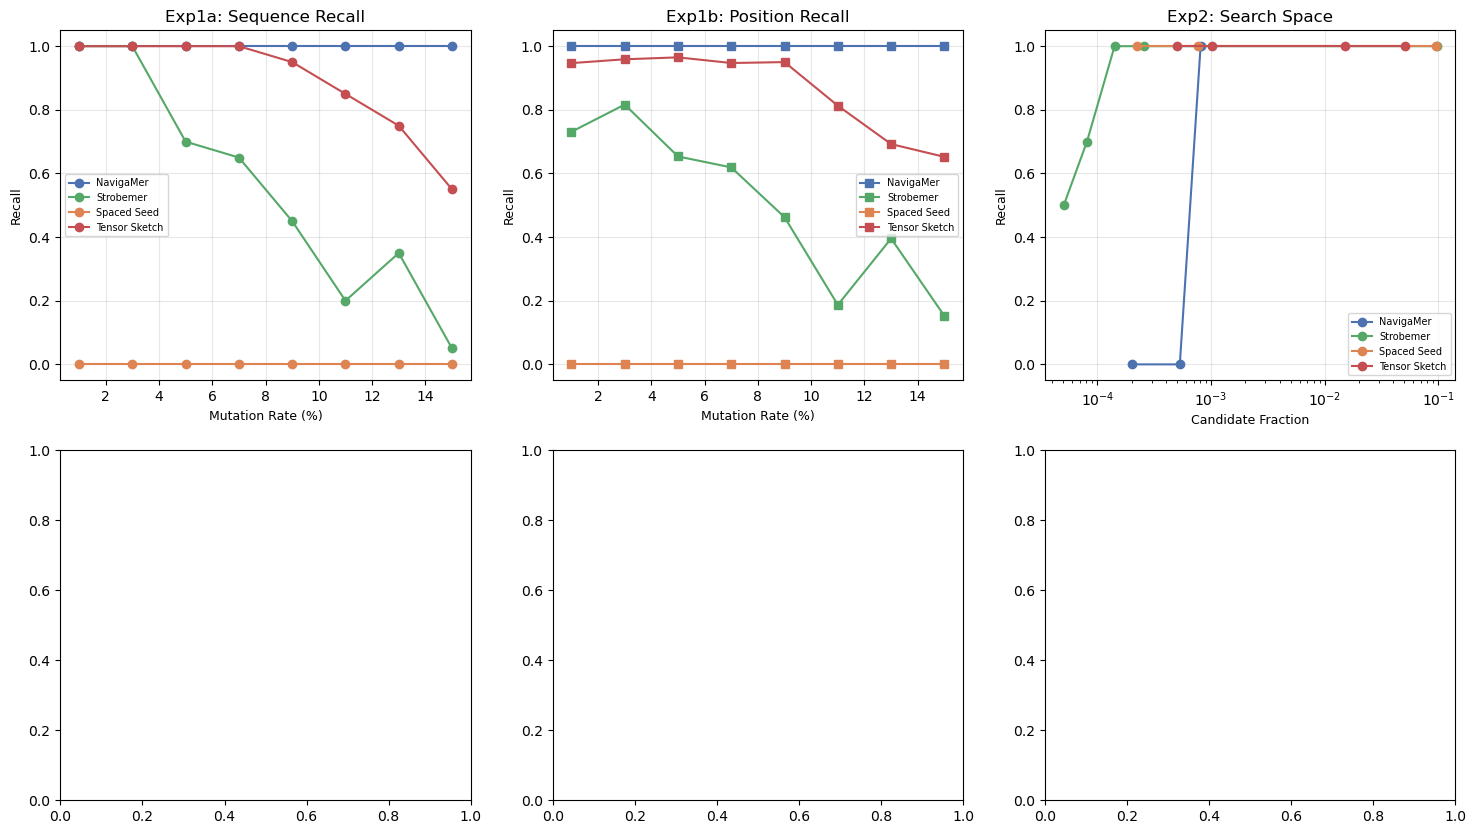

In [13]:
_sc = {"navigamer": "#4C72B0", "strobemer": "#55A868", "spaced_seed": "#DD8452", "tensor_sketch": "#C44E52"}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
xs = [int(mr*100) for mr in MUTATION_RATES]
for method, label in [("navigamer", "NavigaMer"), ("strobemer", "Strobemer"), ("spaced_seed", "Spaced Seed"), ("tensor_sketch", "Tensor Sketch")]:
    ys = [r["recall"] for r in results_exp1[method]]
    axes[0, 0].plot(xs, ys, marker='o', label=label, color=_sc[method])
axes[0, 0].set_xlabel("Mutation Rate (%)", fontsize=9)
axes[0, 0].set_ylabel("Recall", fontsize=9)
axes[0, 0].set_title("Exp1a: Sequence Recall")
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(-0.05, 1.05)

for method, label in [("navigamer", "NavigaMer"), ("strobemer", "Strobemer"), ("spaced_seed", "Spaced Seed"), ("tensor_sketch", "Tensor Sketch")]:
    ys = [r["recall"] for r in results_exp1_pos[method]]
    axes[0, 1].plot(xs, ys, marker='s', label=label, color=_sc[method])
axes[0, 1].set_xlabel("Mutation Rate (%)", fontsize=9)
axes[0, 1].set_ylabel("Recall", fontsize=9)
axes[0, 1].set_title("Exp1b: Position Recall")
axes[0, 1].legend(fontsize=7)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(-0.05, 1.05)

for method, label in [("navigamer", "NavigaMer"), ("strobemer", "Strobemer"), ("spaced_seed", "Spaced Seed"), ("tensor_sketch", "Tensor Sketch")]:
    pts = series_exp2[method]
    axes[0, 2].plot([p["candidate_fraction"] for p in pts], [p["recall"] for p in pts], marker='o', label=label, color=_sc[method])
axes[0, 2].set_xscale("log")
axes[0, 2].set_xlabel("Candidate Fraction", fontsize=9)
axes[0, 2].set_ylabel("Recall", fontsize=9)
axes[0, 2].set_title("Exp2: Search Space")
axes[0, 2].legend(fontsize=7)
axes[0, 2].grid(True, alpha=0.3)

x3 = np.arange(len(keys))
w3 = 0.35
axes[1, 0].bar(x3 - w3/2, [seq_recalls.get(k, 0) for k in keys], w3, label="Seq Recall", color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'], alpha=0.85)
axes[1, 0].bar(x3 + w3/2, [hit_recalls.get(k, 0) for k in keys], w3, label="Hit Recall", color=['#4C72B0', '#55A868', '#DD8452', '#C44E52'], edgecolor='black', linewidth=1.0, alpha=0.55)
axes[1, 0].set_xticks(x3)
axes[1, 0].set_xticklabels(labels, fontsize=7)
axes[1, 0].set_ylabel("Recall", fontsize=9)
axes[1, 0].set_title("Exp3: Comprehensiveness")
axes[1, 0].set_ylim(0, 1.15)
axes[1, 0].legend(fontsize=7)

_all_d4 = [v for vs in dists_by_method.values() for v in vs if v <= 80]
_bins4 = np.arange(0, max(_all_d4) + 2) - 0.5 if _all_d4 else 20
for method, label in [("navigamer", "NavigaMer"), ("strobemer", "Strobemer"), ("spaced_seed", "Spaced Seed"), ("tensor_sketch", "Tensor Sketch")]:
    d = np.array([x for x in dists_by_method.get(method, []) if x <= 80])
    if len(d) > 0:
        axes[1, 1].hist(d, bins=_bins4, alpha=0.45, color=_sc[method],
                        edgecolor=_sc[method], linewidth=0.6, label=label)
axes[1, 1].axvline(15, color="#4C72B0", linestyle="--", linewidth=1.2, alpha=0.7, label="tolerance=15")
axes[1, 1].set_xlabel("Edit Distance", fontsize=9)
axes[1, 1].set_ylabel("Count", fontsize=9)
axes[1, 1].set_title("Exp4: Candidate Quality")
axes[1, 1].legend(fontsize=7)
axes[1, 1].grid(True, alpha=0.2, axis="y")

axes[1, 2].set_visible(False)

plt.suptitle("NavigaMer V3.0 Benchmark Summary", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUTPUT_DIR / "summary.png", bbox_inches='tight')
plt.show()
print("Output dir:", OUTPUT_DIR)